## Objective ##

<span style = "color: black; font-family: arial; font-size: 20px;">
The objective is to analyze the factors that influence the customer turnover from Interconnect company, based on contractual, behavioral and service data used.The company seeks to understand which customer profiles are most likely to cancel their contracts in order to implement preventive strategies such as personalized offers, alternative plans and loyalty actions.

## Loading libraries ##

In [42]:
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import scipy.stats as stats
from scipy.stats import ttest_ind, levene
import pandas as pd
from math import factorial
from plotly import graph_objects as go
from datetime import datetime
import math
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.express as px

## Loading data ##

In [44]:
# Loading 'contract' dataframe
contract = pd.read_csv(r"C:\Users\pedro\Documents\Dataframes projetos\interconnect-churn-analysis\contract.csv")
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [45]:
# Loading 'personal' dataframe
personal = pd.read_csv(r"C:\Users\pedro\Documents\Dataframes projetos\interconnect-churn-analysis\personal.csv")
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [46]:
# Loading 'internet' dataframe
internet = pd.read_csv(r"C:\Users\pedro\Documents\Dataframes projetos\interconnect-churn-analysis\internet.csv")
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [47]:
# Loading 'phone' dataframe
phone = pd.read_csv(r"C:\Users\pedro\Documents\Dataframes projetos\interconnect-churn-analysis\phone.csv")
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


## Data pre-processing

### Dataframe `Contract`

In [50]:
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [51]:
# Verifying duplicates
print(contract.duplicated().sum())

0


In [52]:
# Verifying missing values
print(contract.isna().sum())

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [53]:
# Going through the headers and converting everything into lowercase
new_col_names=[]
for old_name in contract.columns:
    name_lowered=old_name.lower()
    new_col_names.append(name_lowered)
contract.columns=new_col_names
print(contract.columns)

Index(['customerid', 'begindate', 'enddate', 'type', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges'],
      dtype='object')


In [54]:
# Renaming columns
columns_new = {'customerid': 'customer_id',
               'begindate': 'begin_date',
               'enddate': 'end_date',
               'paperlessbilling': 'paperless_billing',
               'paymentmethod': 'payment_method',
               'monthlycharges': 'monthly_charges',
               'totalcharges': 'total_charges'}
contract.rename(columns=columns_new, inplace=True)
print(contract.columns)

Index(['customer_id', 'begin_date', 'end_date', 'type', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges'],
      dtype='object')


In [55]:
# Converting the columns 'begin_date' and 'end_date' into datetime
contract['begin_date'] = pd.to_datetime(contract['begin_date'])
contract['end_date'] = pd.to_datetime(contract['end_date'], errors='coerce')

C:\Users\pedro\AppData\Local\Temp\ipykernel_29988\391300278.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  contract['end_date'] = pd.to_datetime(contract['end_date'], errors='coerce')


In [56]:
# Converting the column 'total_charges' into float64
contract['total_charges'] = pd.to_numeric(contract['total_charges'], errors='coerce')

In [57]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1869 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 440.3+ KB


### Dataframe `personal`

In [59]:
personal.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [60]:
# Verifying duplicates
print(personal.duplicated().sum())

0


In [61]:
# Verifying missing values
print(personal.isna().sum())

customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64


In [62]:
# Going through the headers and converting everything into lowercase
new_col_names=[]
for old_name in personal.columns:
    name_lowered=old_name.lower()
    new_col_names.append(name_lowered)
personal.columns=new_col_names
print(personal.columns)

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents'], dtype='object')


In [63]:
# Renaming columns
columns_new = {'customerid': 'customer_id', 'seniorcitizen': 'senior_citizen'}
personal.rename(columns=columns_new, inplace=True)
print(personal.columns)

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents'], dtype='object')


In [64]:
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   int64 
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


### Dataframe `Internet`

In [66]:
internet.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [67]:
# Verifying duplicates
print(internet.duplicated().sum())

0


In [68]:
# Verifying missing values
print(internet.isna().sum())

customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


In [69]:
# Going through the headers and converting everything into lowercase
new_col_names=[]
for old_name in internet.columns:
    name_lowered=old_name.lower()
    new_col_names.append(name_lowered)
internet.columns=new_col_names
print(internet.columns)

Index(['customerid', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies'],
      dtype='object')


In [70]:
# Renaming columns
columns_new = {'customerid': 'customer_id',
               'internetservice': 'internet_service',
               'onlinesecurity': 'online_security',
               'onlinebackup': 'online_backup',
               'deviceprotection': 'device_protection',
               'techsupport': 'tech_support',
               'streamingtv': 'streaming_tv',
               'streamingmovies': 'streaming_movies'}
internet.rename(columns=columns_new, inplace=True)
print(internet.columns)

Index(['customer_id', 'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies'],
      dtype='object')


In [71]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   object
 3   online_backup      5517 non-null   object
 4   device_protection  5517 non-null   object
 5   tech_support       5517 non-null   object
 6   streaming_tv       5517 non-null   object
 7   streaming_movies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


### Dataframe `Phone`

In [73]:
phone.head()

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [74]:
# Verifying duplicates
print(phone.duplicated().sum())

0


In [75]:
# Verifying missing values
print(phone.isna().sum())

customerID       0
MultipleLines    0
dtype: int64


In [76]:
# Going through the headers and converting everything into lowercase
new_col_names=[]
for old_name in phone.columns:
    name_lowered=old_name.lower()
    new_col_names.append(name_lowered)
phone.columns=new_col_names
print(phone.columns)

Index(['customerid', 'multiplelines'], dtype='object')


In [77]:
# Renaming columns
columns_new = {'customerid': 'customer_id', 'multiplelines': 'multiple_lines'}
phone.rename(columns=columns_new, inplace=True)
print(phone.columns)

Index(['customer_id', 'multiple_lines'], dtype='object')


In [78]:
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


## Exploratory analysis

In [80]:
# Merging all company information about customers
id_merged = contract.merge(personal, on='customer_id')\
             .merge(internet, on='customer_id')\
             .merge(phone, on='customer_id')
id_merged.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
1,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
2,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
3,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Female,0,No,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes
4,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Male,0,No,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes


<span style = "color: black; font-family: arial; font-size: 20px;">
Since there is no explicit churn column, it can be derived from the 'End_date' column indicating whether the customer ended the contract before the date of analysis (01/02/2020).

In [82]:
# Setting the analysis date
analysis_date = pd.to_datetime('2020-02-01')

# If the contract end date is before 02/01/2020, it means that the customer has left
id_merged['churn'] = id_merged['end_date'] < analysis_date

# Checking distribution
id_merged['churn'].value_counts(normalize=True)

churn
False    0.671975
True     0.328025
Name: proportion, dtype: float64

In [83]:
id_merged.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,churn
0,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,...,No,DSL,Yes,No,Yes,No,No,No,No,False
1,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,No,DSL,Yes,Yes,No,No,No,No,No,True
2,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,Fiber optic,No,No,No,No,No,No,No,True
3,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Female,0,...,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes,True
4,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Male,0,...,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes,False


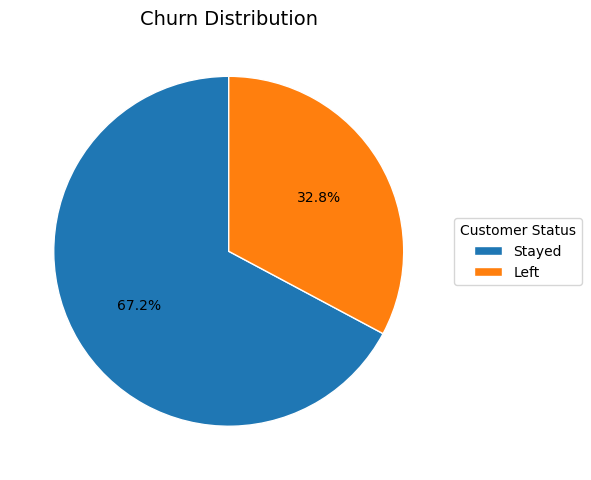

In [84]:
# Calculating churn proportions
churn_dist = id_merged['churn'].value_counts(normalize=True)

# Plotting a pizza chart
labels1 = churn_dist.index.map({True: 'Left', False: 'Stayed'})
plt.figure(figsize=(6, 6))
plt.pie(churn_dist, labels=None, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
plt.title('Churn Distribution', fontsize=14)
plt.legend(labels1, title="Customer Status", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


<span style = "color: black; font-family: arial; font-size: 20px;">
If the contract's customer ending is prior to 02/02/2020, it means that he left. If the date is after 02/02/2020, it means that the customer stayed.

## Contract Type vs VS turnover

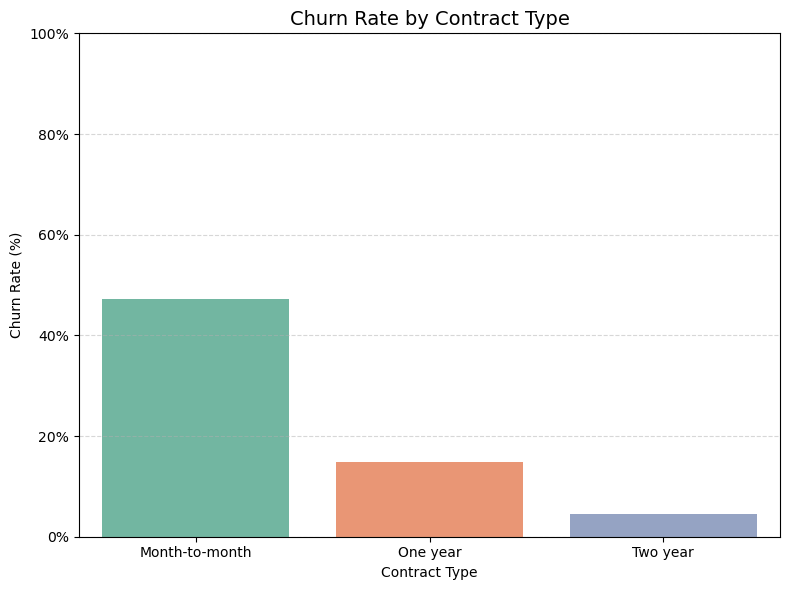

In [87]:
# Calculando a taxa de churn por tipo de contrato
churn_by_contract = id_merged.groupby('type')['churn'].mean().reset_index()
churn_by_contract.rename(columns={'churn': 'churn_rate'}, inplace=True)

# Plotando gráfico
plt.figure(figsize=(8, 6))
sns.barplot(data=churn_by_contract, x='type', y='churn_rate', hue='type', palette='Set2')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<span style = "color: black; font-family: arial; font-size: 20px;">
Customers with smaller contracts are more likely to leave.The one-month contract has a turnover rate of over 40%.

## Revenue growth vs Rotativity

<span style = "color: Blue; Font-Family: Arial; Font-Size: 20px;">
Calculating revenue growth per customer and checking its relation with churn.

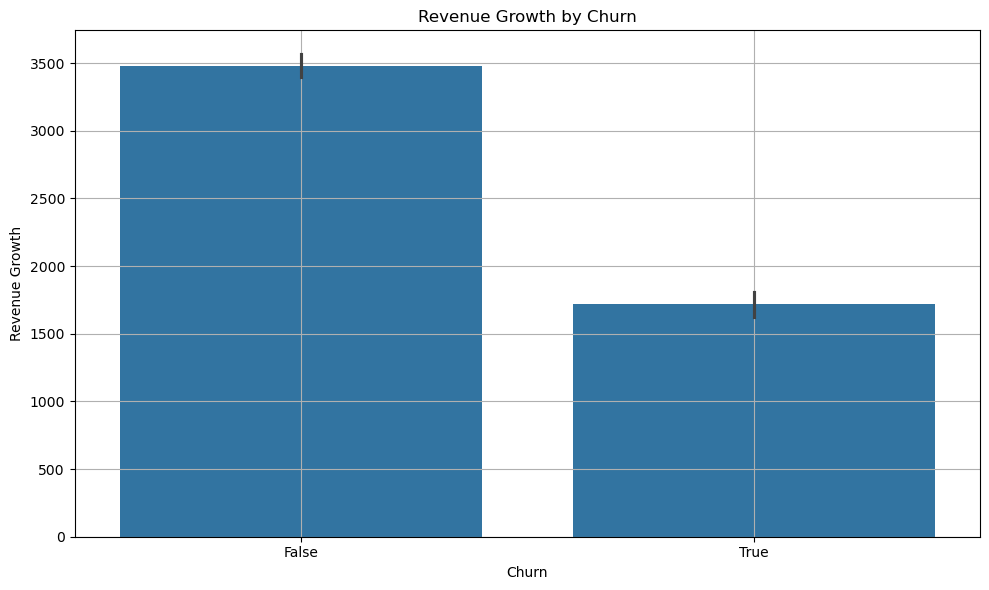

In [202]:
# Plotting a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=id_merged, x='churn', y='total_charges')
plt.title('Revenue Growth by Churn')
plt.xlabel('Churn')
plt.ylabel('Revenue Growth')
plt.grid(True)
plt.tight_layout()
plt.show()

<span style = "color: black; font-family: arial; font-size: 20px;">
Customers who did not leave had a greater revenue growth than customers who left.

C:\Users\pedro\AppData\Local\Temp\ipykernel_29988\2049740847.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_churn = id_merged.groupby('revenue_group')['churn'].mean()


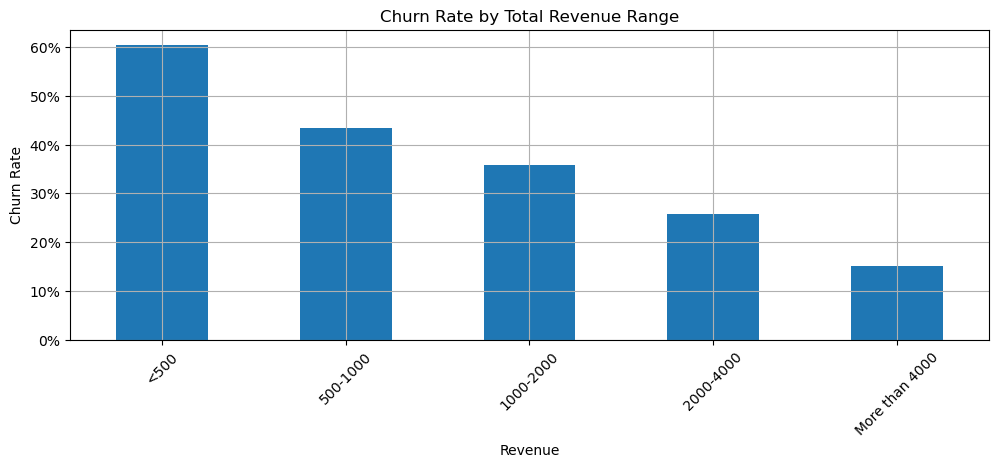

In [93]:
# Classifying revenues into ranges
bins = [0, 500, 1000, 2000, 4000, id_merged['total_charges'].max()]
labels = ['<500', '500-1000', '1000-2000', '2000-4000', 'More than 4000']
id_merged['revenue_group'] = pd.cut(id_merged['total_charges'], bins=bins, labels=labels)

# Churn rate by group
revenue_churn = id_merged.groupby('revenue_group')['churn'].mean()

# Plotting a bar chart
revenue_churn.plot(kind='bar', figsize=(10,5), title='Churn Rate by Total Revenue Range')
plt.ylabel('Churn Rate')
plt.xlabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.show()

<span style = "color: black; font-family: arial; font-size: 20px;">
Customers who spend less than $ 500 have a churn rate of 60%.

## Payment frequency vs. Churn

<span style = "color: Blue; Font-Family: Arial; Font-Size: 20px;">
Calculating average frequency of payments

In [97]:
# Adding the 'months_active' column
id_merged['months_active'] = id_merged['total_charges'] / id_merged['monthly_charges']
id_merged.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,churn,revenue_group,months_active
0,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,...,Yes,No,Yes,No,No,No,No,False,1000-2000,33.178227
1,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,Yes,Yes,No,No,No,No,No,True,<500,2.008357
2,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,No,No,No,No,No,No,True,<500,2.144979
3,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Female,0,...,No,No,Yes,No,Yes,Yes,Yes,True,500-1000,8.233818
4,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Male,0,...,No,Yes,No,No,Yes,No,Yes,False,1000-2000,21.878788


<span style = "color: Blue; Font-Family: Arial; Font-Size: 20px;">
Grouping by permanence range

In [99]:
# Creating range times
bins = [0, 6, 12, 24, 36, 60]
labels = ['Up to 6 months', '6-12 months', '12-24 months', '24-36 months', 'More than 36 months']
id_merged['payment_freq_group'] = pd.cut(id_merged['months_active'], bins=bins, labels=labels)

C:\Users\pedro\AppData\Local\Temp\ipykernel_29988\2193562404.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_churn = id_merged.groupby('payment_freq_group')['churn'].value_counts(normalize=True).unstack().fillna(0)


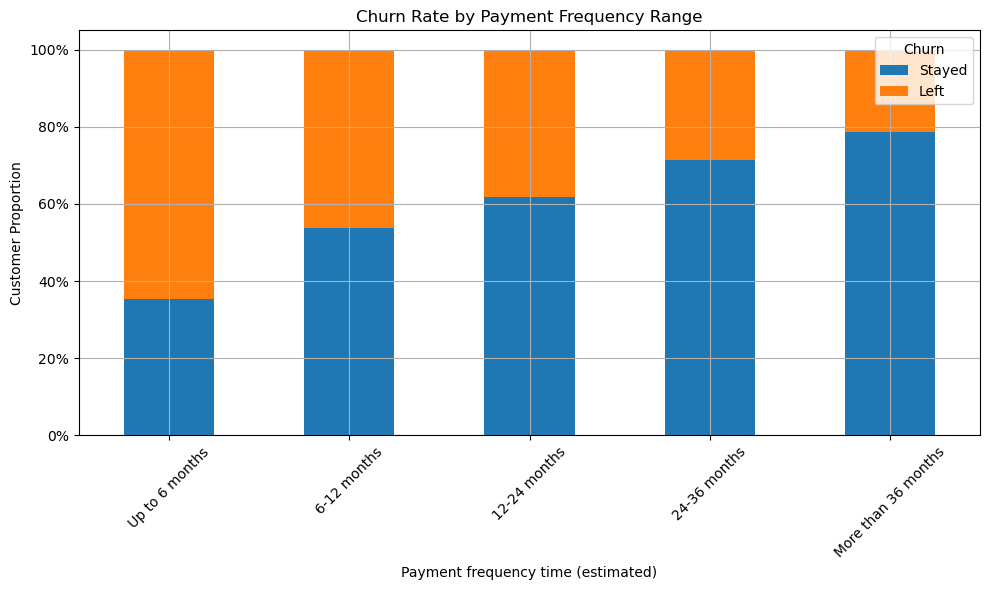

In [100]:
# Grouping by payment frequency and churn
freq_churn = id_merged.groupby('payment_freq_group')['churn'].value_counts(normalize=True).unstack().fillna(0)

# Plotting a bar chart
freq_churn.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Churn Rate by Payment Frequency Range')
plt.xlabel('Payment frequency time (estimated)')
plt.ylabel('Customer Proportion')
plt.legend(['Stayed', 'Left'], title='Churn')
plt.grid(True)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<span style = "color: black; font-family: arial; font-size: 20px;">
The longer customers make payments to the company, more they tend to stay. Customers who pay for over 3 years are almost 80% of those still in the company.

<span style = "color: Blue; Font-Family: Arial; Font-Size: 20px;">
Calculating average frequency of payment by contract type

In [103]:
# Adding contract stats to the merged dataframe
contract_stats = id_merged.groupby('type').agg({
    'months_active': 'mean',
    'churn': 'mean',
    'customer_id': 'count'
}).rename(columns={
    'months_active': 'avg_months_active',
    'churn': 'churn_rate',
    'customer_id': 'total_customers'
}).sort_values('avg_months_active', ascending=False)

contract_stats.head()


,avg_months_active,churn_rate,total_customers
type,,,
Two year,62.926134,0.044643,896
One year,47.144606,0.148340,964
Month-to-month,19.519436,0.471597,2975


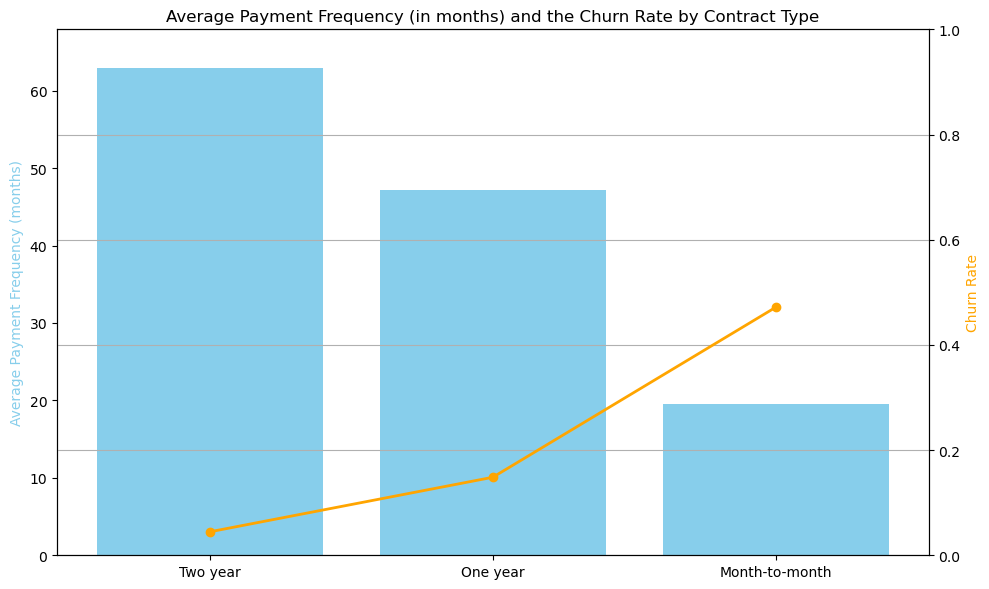

In [104]:
# Plotting a chart
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(contract_stats.index, contract_stats['avg_months_active'], color='skyblue', label='Média de meses ativos')
ax1.set_ylabel('Average Payment Frequency (months)', color='skyblue')
ax1.set_ylim(0, contract_stats['avg_months_active'].max() + 5)
ax2 = ax1.twinx()
ax2.plot(contract_stats.index, contract_stats['churn_rate'], color='orange', marker='o', linewidth=2, label='Churn Rate')
ax2.set_ylabel('Churn Rate', color='orange')
ax2.set_ylim(0, 1)
plt.title('Average Payment Frequency (in months) and the Churn Rate by Contract Type')
fig.tight_layout()
plt.grid(True)
plt.show()


<span style = "color: black; font-family: arial; font-size: 20px;">
Customers with a higher average frequency of payments are those who have a 2 year contract. The churn rate grows as customer contracts are smaller.

## Internet service type vs. Churn

<span style = "color: Blue; Font-Family: Arial; Font-Size: 20px;">
Checking if the type of internet influences churn rate

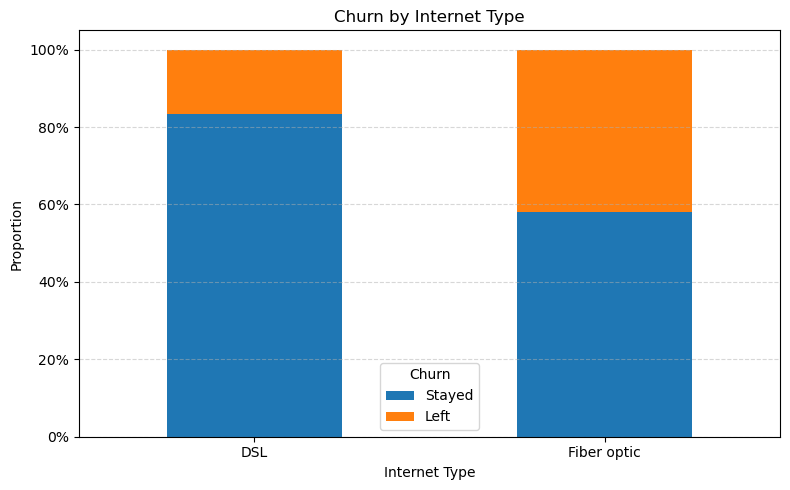

In [108]:

# Grouping churn by internet type and plotting a chart
churn_by_internet = id_merged.groupby('internet_service')['churn'].value_counts(normalize=True).unstack()
churn_by_internet.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Churn by Internet Type')
plt.ylabel('Proportion')
plt.xlabel('Internet Type')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(['Stayed', 'Left'], title='Churn')
plt.tight_layout()
plt.show()



<span style = "color: black; font-family: arial; font-size: 20px;">
Customers who used fiber optics left the company more than those who used DSL.

## Age Range vs VS Churn

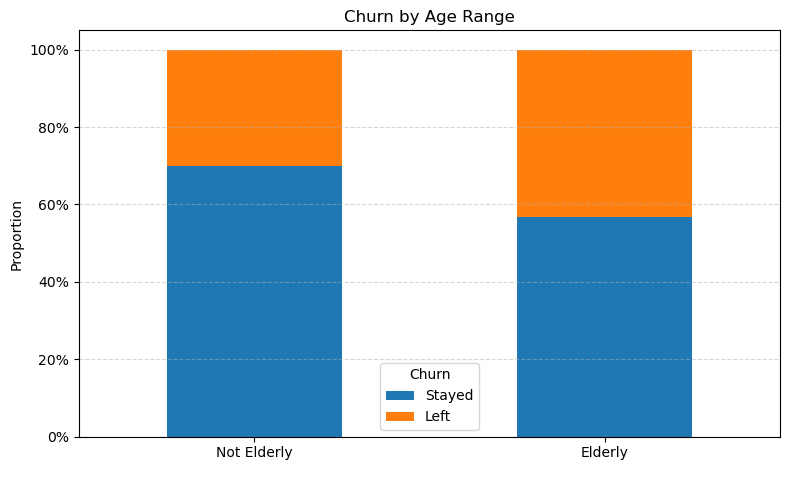

In [111]:

# Grouping churn by age group and plotting a chart
id_merged.groupby('senior_citizen')['churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True, figsize=(8,5), title='Churn by Age Range'
)
plt.ylabel('Proportion')
plt.xlabel(' ')
plt.xticks([0, 1], ['Not Elderly', 'Elderly'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Stayed', 'Left'], title='Churn')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


<span style = "color: black; font-family: arial; font-size: 20px;">
Elderly customers tend to leave more than clients who are not elderly.

## Multiple telephone lines vs Churn

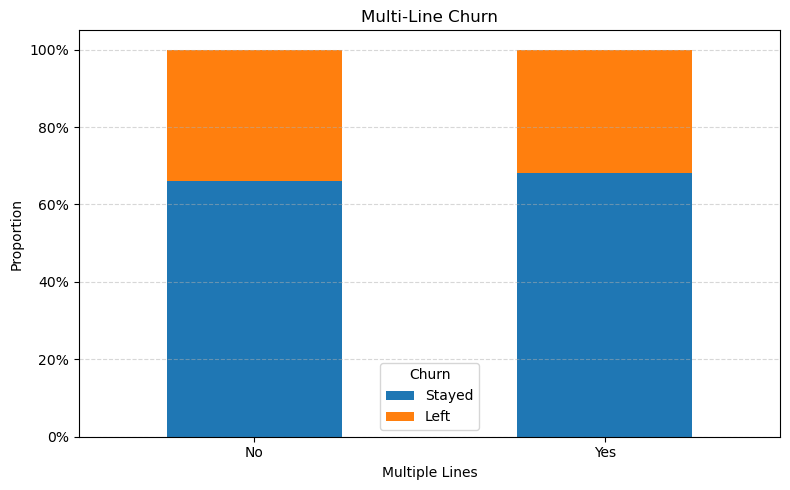

In [114]:
# Agrupando rotatividade por clientes que tem multiplas linhas e construindo um gráfico representativo
id_merged.groupby('multiple_lines')['churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True, figsize=(8,5), title='Multi-Line Churn'
)
plt.ylabel('Proportion')
plt.xlabel('Multiple Lines')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Stayed', 'Left'], title='Churn')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

<span style = "color: black; font-family: arial; font-size: 20px;">
The proportion of customers with or without multiple lines did not impact churn significantly.

## Customers who have partners vs. Churn

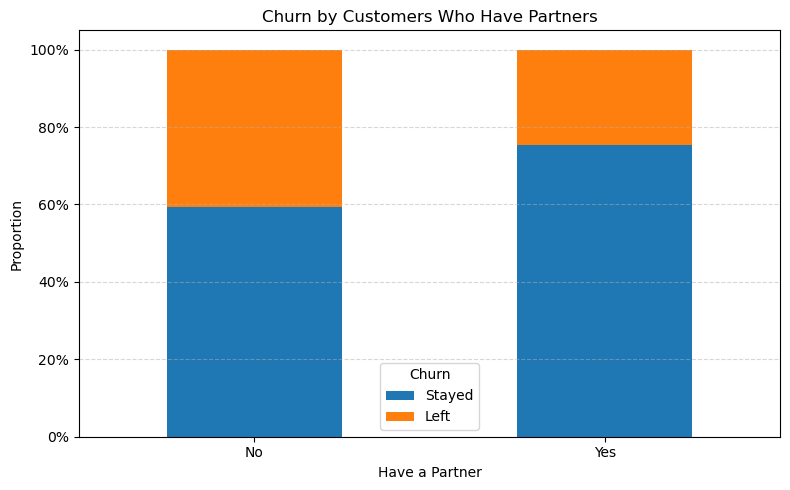

In [117]:

# Grouping churn by customers who have partners and plotting a chart
id_merged.groupby('partner')['churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True, figsize=(8,5), title='Churn by Customers Who Have Partners'
)
plt.ylabel('Proportion')
plt.xlabel('Have a Partner')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Stayed', 'Left'], title='Churn')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


<span style = "color: black; font-family: arial; font-size: 20px;">
Customers who have partners is more likely to stay in the company than those who do not have.

## Customers who have dependents vs. Churn

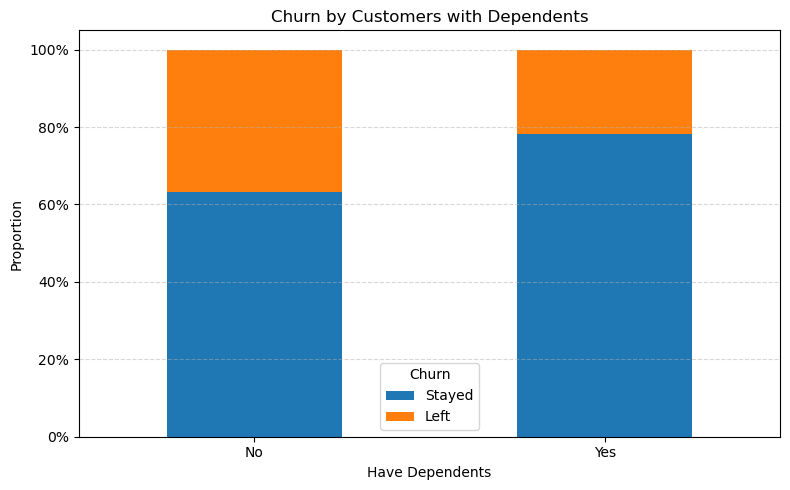

In [120]:
# Agrupando rotatividade por clientes que possuem dependentes e construindo um gráfico representativo
id_merged.groupby('dependents')['churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True, figsize=(8,5), title='Churn by Customers with Dependents'
)
plt.ylabel('Proportion')
plt.xlabel('Have Dependents')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Stayed', 'Left'], title='Churn')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


<span style = "color: black; font-family: arial; font-size: 20px;">
Customers who have dependents also tend to stay in the company than those who do not have.

## Time since last purchase vs Churn

<span style = "color: Blue; Font-Family: Arial; Font-Size: 20px;">
Identify the latest purchase date of each customer and calculate the time since the last purchase

In [124]:
# Identifying each customer's last purchase date
id_merged['last_purchase_date'] = pd.to_datetime(id_merged['end_date'], errors='coerce').fillna(pd.to_datetime('2020-02-01'))
id_merged['days_since_last_purchase'] = (pd.to_datetime('2020-02-01') - id_merged['last_purchase_date']).dt.days
id_merged.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,tech_support,streaming_tv,streaming_movies,multiple_lines,churn,revenue_group,months_active,payment_freq_group,last_purchase_date,days_since_last_purchase
0,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,...,No,No,No,No,False,1000-2000,33.178227,24-36 months,2020-02-01,0
1,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,No,No,No,No,True,<500,2.008357,Up to 6 months,2019-12-01,62
2,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,No,No,No,True,<500,2.144979,Up to 6 months,2019-11-01,92
3,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Female,0,...,No,Yes,Yes,Yes,True,500-1000,8.233818,6-12 months,2019-11-01,92
4,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Male,0,...,No,Yes,No,Yes,False,1000-2000,21.878788,12-24 months,2020-02-01,0


<span style = "color: Blue; Font-Family: Arial; Font-Size: 20px;">
Creating categories based on time since the last customer purchase

In [126]:
bins = [-1, 30, 90, 180, 365, 9999]
labels = ['<1 month', '1-3 months', '3-6 months', '6-12 months', 'More than 1 year']
id_merged['recency_category'] = pd.cut(id_merged['days_since_last_purchase'], bins=bins, labels=labels)

C:\Users\pedro\AppData\Local\Temp\ipykernel_29988\3326359979.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recency_churn = id_merged.groupby('recency_category')['churn'].agg(['mean', 'count'])


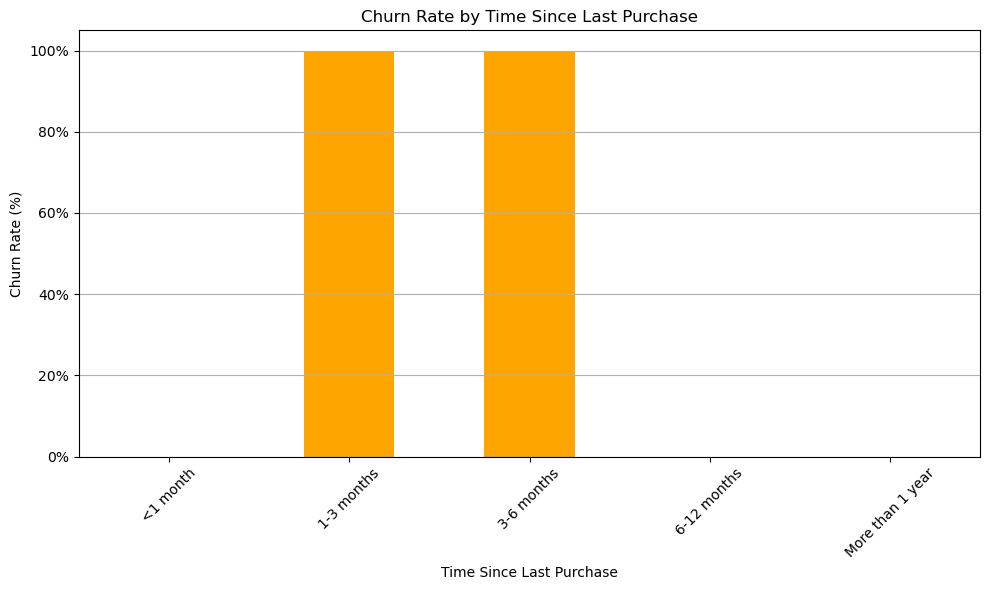

In [127]:
# Grouping time since last purchase with churn
recency_churn = id_merged.groupby('recency_category')['churn'].agg(['mean', 'count'])

recency_churn.rename(columns={'mean': 'churn_rate'}, inplace=True)

# Plotting a chart
plt.figure(figsize=(10,6))
recency_churn['churn_rate'].plot(kind='bar', color='orange')
plt.title('Churn Rate by Time Since Last Purchase')
plt.xlabel('Time Since Last Purchase')
plt.ylabel('Churn Rate (%)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<span style = "color: black; font-family: arial; font-size: 20px;">
Customers who made their last purchase between 1 and 6 months have more chances in leaving the company.

## Hypothesis' tests

<span style = "color: Blue; Font-Family: Arial; Font-Size: 20px;">
Test: Customers who generate a revenue growth below average are more likely to leave.

In [131]:
# H₀: Customers who generate a revenue growth below average are not more likely to leave.
# H₁: Customers who generate a revenue growth below average are more likely to leave.

In [132]:
# Only clients that have 'end_date' known
df_test = id_merged[id_merged['total_charges'].notna()]

group_churned = df_test[df_test['churn'] == True]['total_charges']
group_retained = df_test[df_test['churn'] == False]['total_charges']

# Apllying Levene Test
stat_levene, p_levene = levene(group_churned, group_retained)
equal_var = p_levene > 0.05
print(f"Levene's Test: {stat_levene:.4f}, p-value: {p_levene:.4f}")

Levene's Test: 249.7567, p-value: 0.0000


<span style = "color: black; font-family: arial; font-size: 20px;">
Levene test indicates that the variances are different (p-value <0.05), so the correct is to use 'equal_var = false' in the T test.

In [134]:
# Only clients that have 'end_date' known
df_test = id_merged[id_merged['total_charges'].notna()]

group_churned = df_test[df_test['churn'] == True]['total_charges']
group_retained = df_test[df_test['churn'] == False]['total_charges']

t_stat1, pval1 = ttest_ind(group_churned, group_retained, equal_var=False)

print(f'T Test: {t_stat1:.4f}, p-value: {pval1:.4f}')
print("The difference between the groups is statistically significant"
      if pval1 < 0.05 else "No significant difference")

T Test: -27.1102, p-value: 0.0000
The difference between the groups is statistically significant


<span style = "color: black; font-family: arial; font-size: 20px;">
Based on the result (p-value <0.05), the null hypothesis should be rejected and considered that customers who generate a revenue growth below average are more likely to leave.

<span style = "color: Blue; Font-Family: Arial; Font-Size: 20px;">
Test: Customers whose last purchase was made long ago are more likely to leave.

In [137]:
# H₀: Customers whose last purchase was made long ago are not more likely to leave.
# H₁: Customers whose last purchase was made long ago are more likely to leave.

In [138]:
# Only clients that have 'days_since_last_purchase' known
df_test = id_merged[id_merged['days_since_last_purchase'].notna()].copy()

group_churned1 = df_test[df_test['churn'] == True]['days_since_last_purchase']
group_retained1 = df_test[df_test['churn'] == False]['days_since_last_purchase']

stat_levene, p_levene = levene(group_churned1, group_retained1)
equal_var = p_levene > 0.05
print(f"Levene's Test: {stat_levene:.4f}, p-value: {p_levene:.4f}")

Levene's Test: 6217.3127, p-value: 0.0000


<span style = "color: black; font-family: arial; font-size: 20px;">
Levene's test indicates that the variances are different (p-value <0.05), so it would be correct to use 'equal_var = false' in the T test.

In [140]:
# Only clients that have 'days_since_last_purchase' known
df_test = id_merged[id_merged['days_since_last_purchase'].notna()].copy()

group_churned1 = df_test[df_test['churn'] == True]['days_since_last_purchase']
group_retained1 = df_test[df_test['churn'] == False]['days_since_last_purchase']

t_stat1, pval1 = ttest_ind(group_churned1, group_retained1, equal_var=False)

print(f'Teste T - Estatística: {t_stat1:.4f}, p-valor: {pval1:.4f}')
print("The difference between the groups is statistically significant"
      if pval1 < 0.05 else "No significant difference")

Teste T - Estatística: 91.2211, p-valor: 0.0000
The difference between the groups is statistically significant


<span style = "color: black; font-family: arial; font-size: 20px;">

Based on the result (p-value <0.05), the null hypothesis should be rejected and considered that customers whose last purchase was in a long time ago are more likely to leave.

## Conclusions and recommendations

<span style = "color: black; font-family: arial; font-size: 20px;">
The analysis allowed us to identify consistent patterns among customers who remained at the comapany and those who canceled their contracts. It was observed that customers with greater financial engagement and long-term relationship tend to stay longer with the company.

Factors such as revenue growth, permanence time, contract type, last purchase date and the use of specific services (such as DSL Internet) were relevant in customer retention. On the other hand, the analysis also revealed that **elderly customers**, **customers without dependents or partners**, **customers with short contracts** and ** customers with fiber optical** presented higher churn rate.

Statistical tests confirmed that:

- Customers who generate a revenue growth below average are more likely to leave.
- Customers whose last purchase was in a long time ago are more likely to leave.

As recommendations to reduce customer churn:

1. **Retention campaigns** to customers:
- with **low revenue growth**;
- with **less than 1 year of active contract**;
- **have not purchased anything for over 30 days**.

2. **Incentives for fiber optic users**, especially in the first months of contract, in order to reduce churning rate in this group.

3. **Promotions and plans that encourage longer contracts**, with progressive rewards and loyalty.

4. **Actions for high -risk profiles**, such as:
- **Elderly customers without dependents/partners**: A personalized support and simplified plans would be welcome for this audience.

5. **Inactive customers monitoring**:
- Monitor **the time since the customer made the last purchase**.

6. **Appreciation of Fidelity**:
- Customers with more than **3 years of contract** have significantly lower churn rates. Rewards and recognitions can help keep this audience faithful.